In [20]:
# ===========================================================
# SMARTHEART: INTELLIGENT HEART DISEASE RISK PREDICTION SYSTEM
# ===========================================================

In [21]:
# Step 1 : Import the libraries
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    roc_curve, 
    roc_auc_score, 
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [22]:
# Step 2 : Load the dataset
# -----------------------------------------------------------

df = pd.read_csv("cleaned_merged_dataset.csv")
print("Dataset Loaded Successfully")
print(df.head())
print(df.info())

Dataset Loaded Successfully
   age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
0   63    1   3       145   233    1        0       150      0      2.3   
1   37    1   2       130   250    0        1       187      0      3.5   
2   41    0   1       130   204    0        0       172      0      1.4   
3   56    1   1       120   236    0        1       178      0      0.8   
4   57    0   0       120   354    0        1       163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   c

In [23]:
# Step 3 : Check and handle the missing values
# -----------------------------------------------------------

# Numeric → median
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values handled.\n")


Missing values handled.



In [24]:
# Step 4 : Feature selection and target split
# -----------------------------------------------------------

X = df.drop("target", axis=1)
y = df["target"]

print("Feature matrix and target vector prepared.")

Feature matrix and target vector prepared.


In [25]:
# Step 5 : Train-test split
# -----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train-test split completed.")

Train-test split completed.


In [26]:
# Step 6 : Feature scaling
# -----------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied.")

Feature scaling applied.


In [27]:
# Step 7 : Initialize models
# -----------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naive Bayes": GaussianNB()
}

print("\nModels initialized.\n")


Models initialized.



In [28]:
# Step 8 : Train models and evaluate
# -----------------------------------------------------------

results = {}

print("Model Performance Metrics:\n")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results[name] = [acc, prec, rec, f1]
    
    print(f"{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}\n")

Model Performance Metrics:

Logistic Regression:
  Accuracy:  0.7125
  Precision: 0.6935
  Recall:    0.7952
  F1 Score:  0.7409

Decision Tree:
  Accuracy:  0.8801
  Precision: 0.8713
  Recall:    0.9010
  F1 Score:  0.8859

Random Forest:
  Accuracy:  0.9700
  Precision: 0.9631
  Recall:    0.9795
  F1 Score:  0.9712

Naive Bayes:
  Accuracy:  0.6914
  Precision: 0.6735
  Recall:    0.7816
  F1 Score:  0.7235



In [29]:
# Step 9 : Select the best model
# -----------------------------------------------------------

best_model_name = max(results, key=lambda x: results[x][0])
best_model = models[best_model_name]

print(f"\nBest Model Selected: {best_model_name}\n")


Best Model Selected: Random Forest



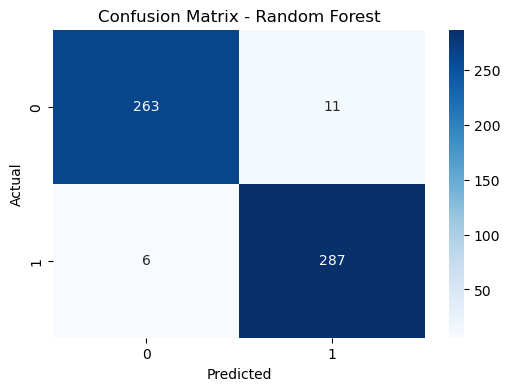

In [30]:
# Step 10 : Confusion matrix visualization
# -----------------------------------------------------------

y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

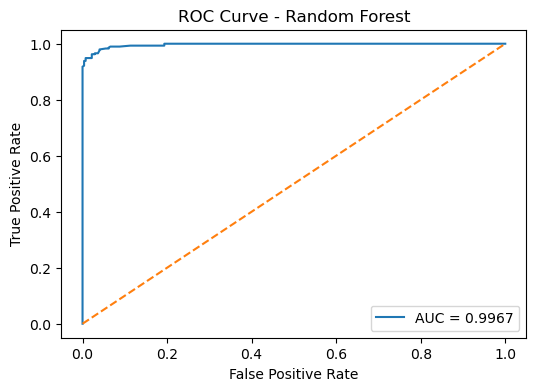

In [31]:
# Step 11 : ROC curve & AUC score
# -----------------------------------------------------------

if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test_scaled)[:,1]
else:
    y_proba = best_model.predict(X_test_scaled)

fpr, tpr, threshold = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()

In [32]:
# Step 12 : Display classification report
# -----------------------------------------------------------

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       274
           1       0.96      0.98      0.97       293

    accuracy                           0.97       567
   macro avg       0.97      0.97      0.97       567
weighted avg       0.97      0.97      0.97       567



In [33]:
# Step 13 : Decision tree visualization (only if appliacble)
# -----------------------------------------------------------

if isinstance(best_model, DecisionTreeClassifier):
    plt.figure(figsize=(20,10))
    plot_tree(best_model, filled=True, feature_names=X.columns, class_names=["No Disease", "Disease"])
    plt.show()

In [34]:
# Step 14 : Final prediction function
# -----------------------------------------------------------

def predict_patient(input_list):
    """
    input_list: a list of feature values (length must match X columns)
    """
    arr = np.array(input_list).reshape(1, -1)
    arr_scaled = scaler.transform(arr)
    pred = best_model.predict(arr_scaled)[0]
    
    return "High Risk of Heart Disease" if pred == 1 else "Low Risk of Heart Disease"

print("\nPrediction function ready for deployment.")


Prediction function ready for deployment.
